In [1]:
from transformers import AutoTokenizer, AutoModel
import torch


from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier

from src.data_loader import load_data
from src.ML.train_NN import train_model
from src.ML.train_NN import train_model_sample_weights
from src.ML.train_NN import train_model_class_weights_and_sampling
from src.ML.train_NN import train_minilm_nn

DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"
df = load_data(DATA_PATH)

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


In [2]:
print(df["Category"].value_counts(normalize=True))

device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  



Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-5): 6 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)


Loaded embedding cache.
Saved cache with 1386 entries.

Classification Report:
              precision    recall  f1-score   support

           0     0.7596    0.7822    0.7707       101
           1     0.3714    0.3421    0.3562        38

    accuracy                         0.6619       139
   macro avg     0.5655    0.5621    0.5634       139
weighted avg     0.6535    0.6619    0.6574       139

Final Test Accuracy: 0.6619


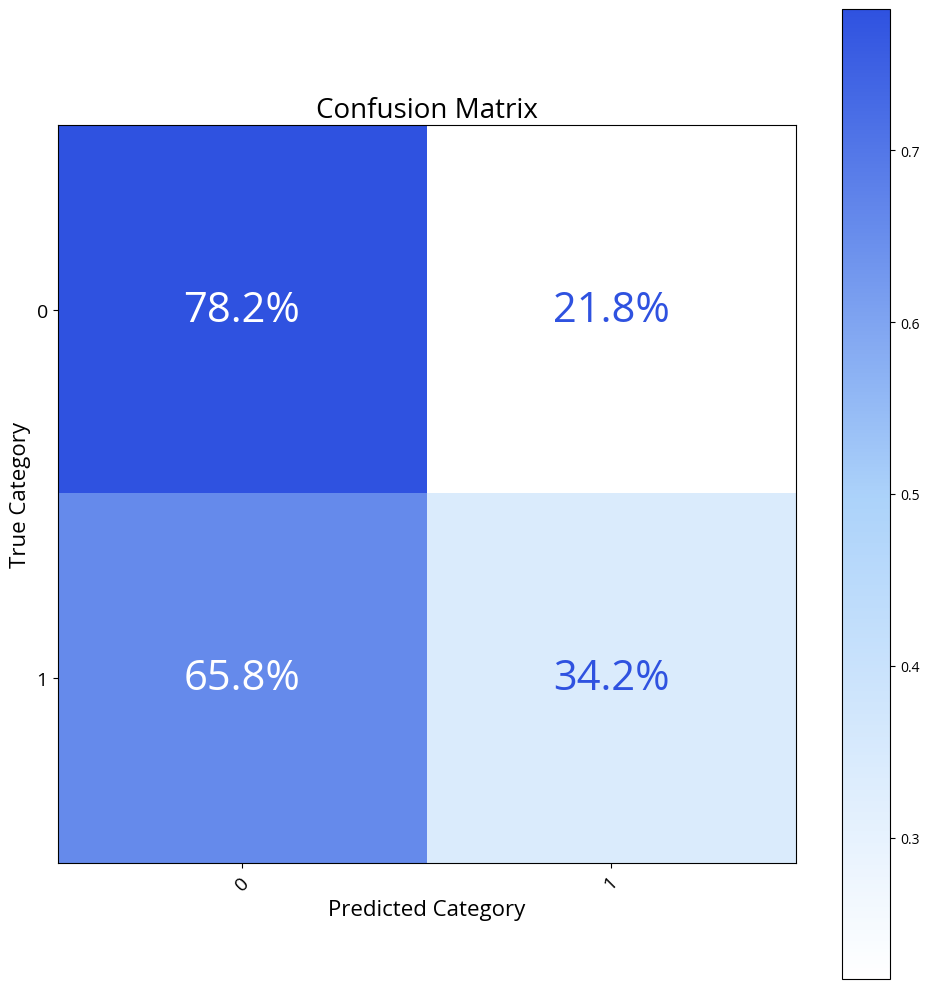

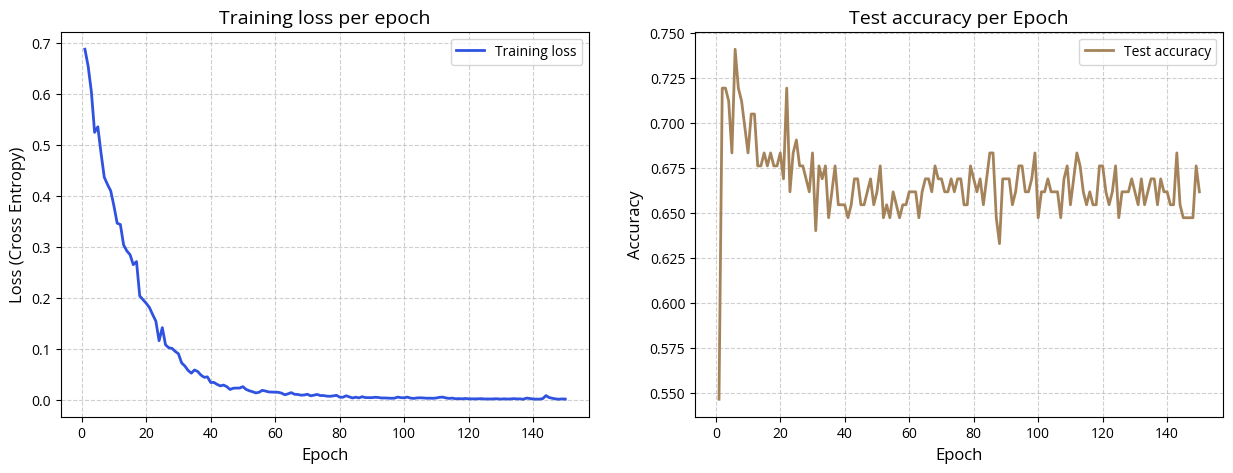

<Figure size 640x480 with 0 Axes>

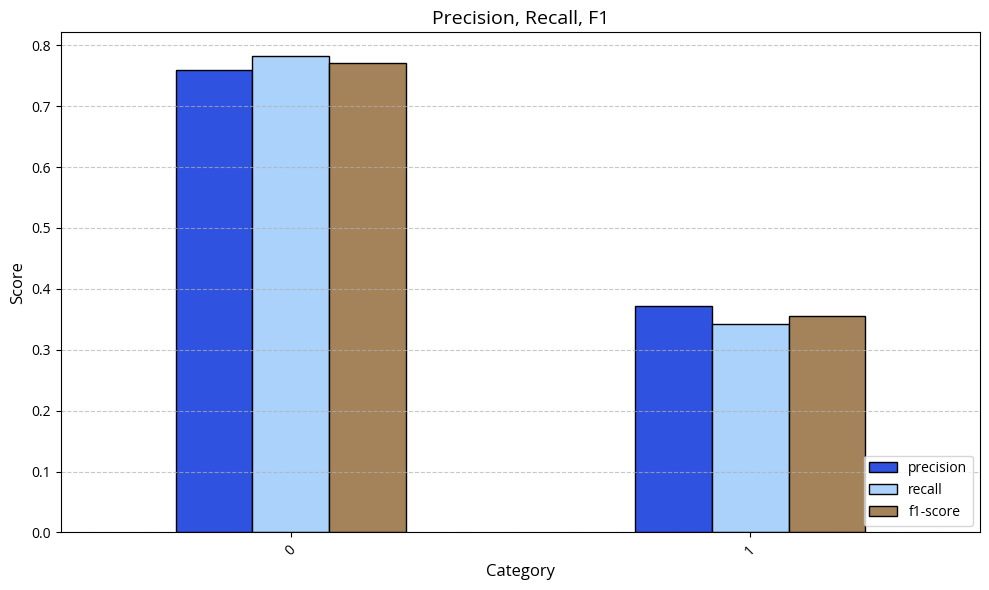

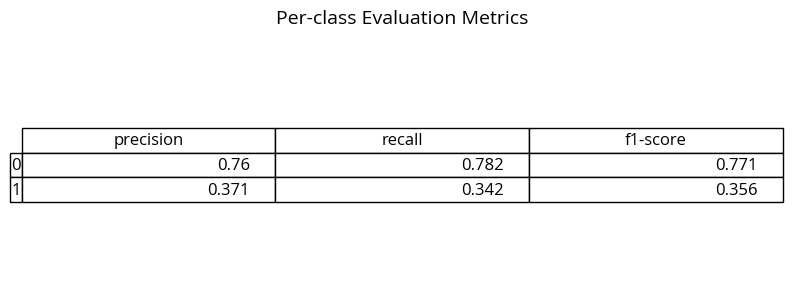

In [3]:
#Simple Feed Forward NN - MiniLM
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

model, class_to_idx, acc = train_model_sample_weights(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=150,
    lr=0.001
)

Loaded embedding cache.
Saved cache with 1386 entries.
Class weights: tensor([0.6869, 3.6755], device='cuda:0')
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       101
           1       0.42      0.47      0.44        38

    accuracy                           0.68       139
   macro avg       0.61      0.61      0.61       139
weighted avg       0.69      0.68      0.68       139



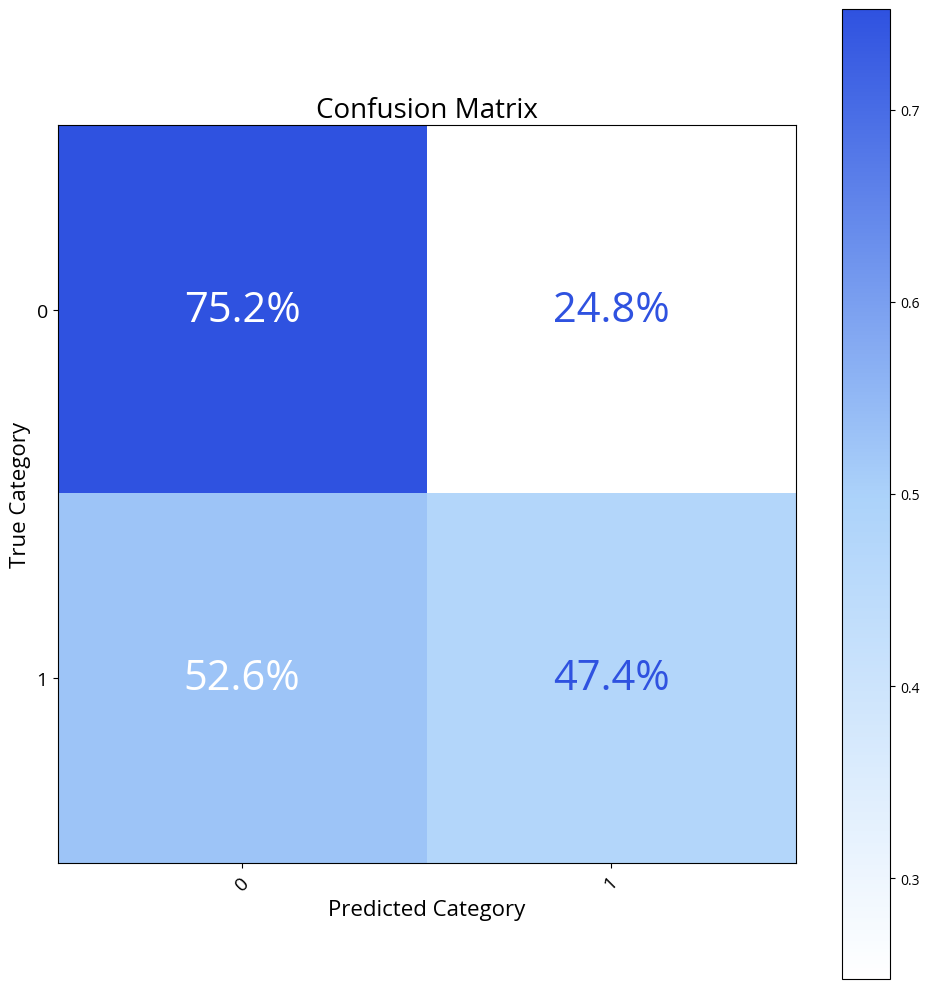

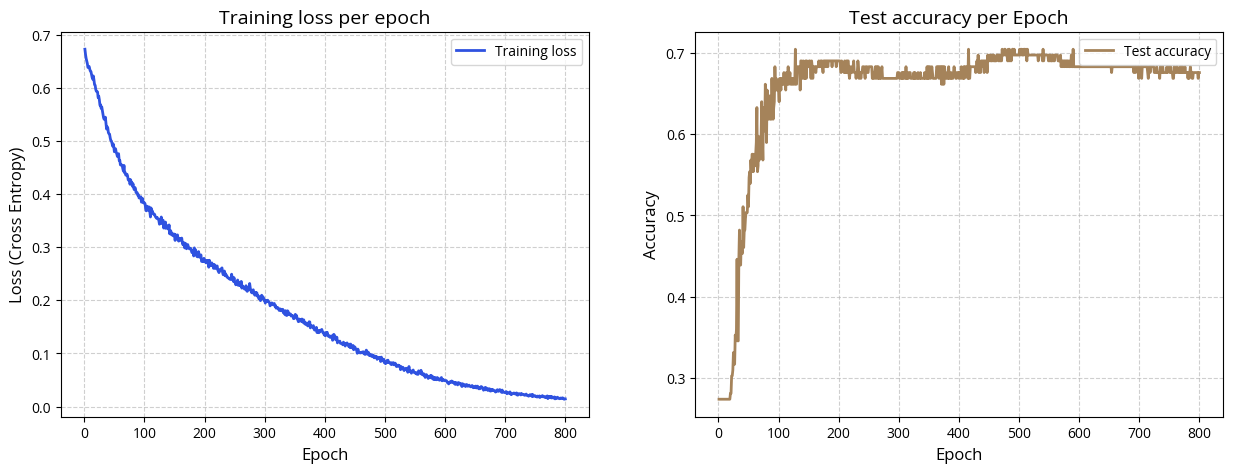

<Figure size 640x480 with 0 Axes>

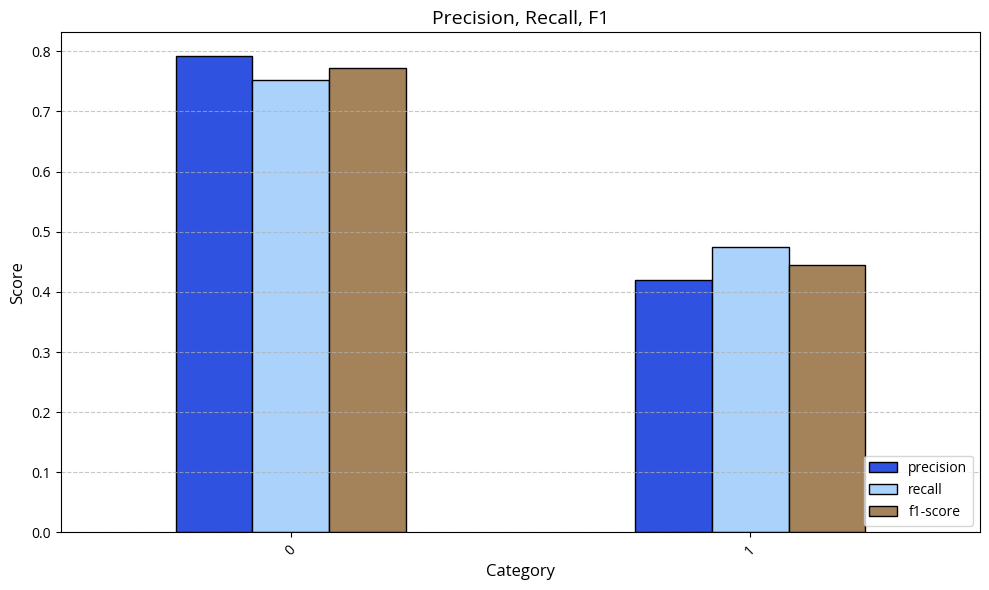

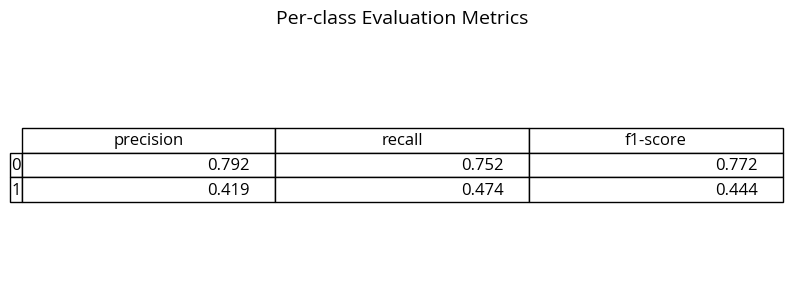

In [4]:
#Simple Feed Forward NN - MiniLM 
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

# manual booster for class 1

model, class_to_idx = train_minilm_nn(
     X_train_vec, y_train,
    X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 180},
    epochs=800,
    lr=0.0002
)


Loaded embedding cache.
Saved cache with 1386 entries.
Class weights: tensor([0.6869, 3.6755], device='cuda:0')
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       101
           1       0.46      0.45      0.45        38

    accuracy                           0.71       139
   macro avg       0.63      0.62      0.63       139
weighted avg       0.70      0.71      0.70       139



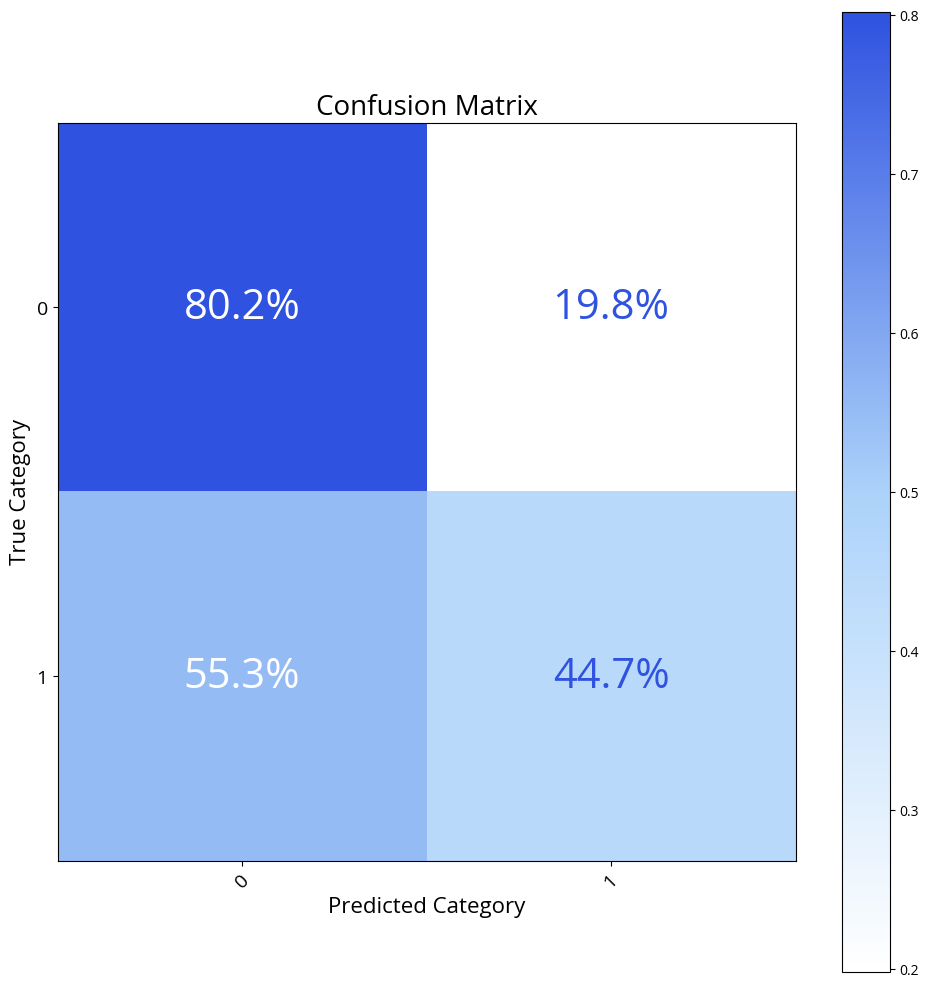

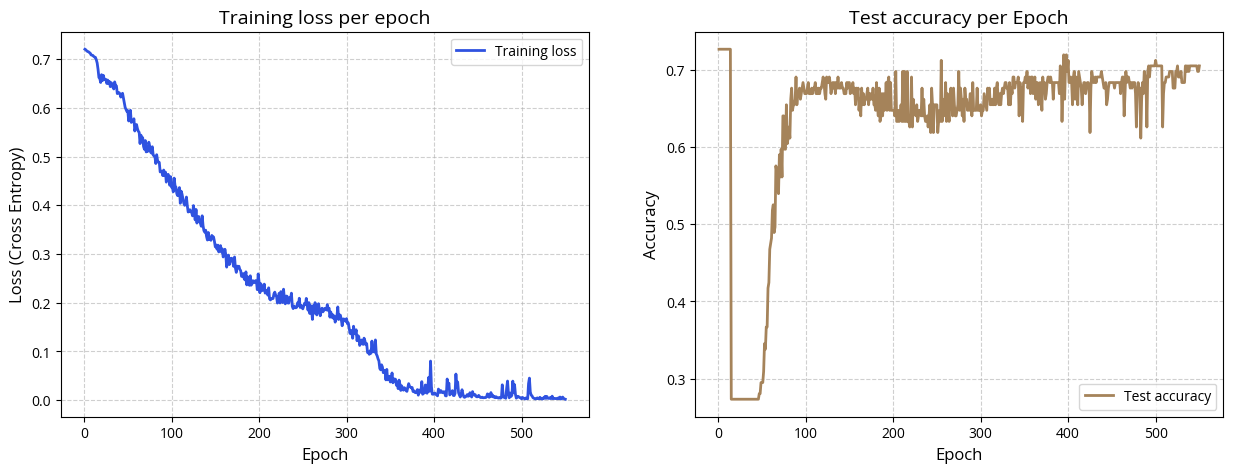

<Figure size 640x480 with 0 Axes>

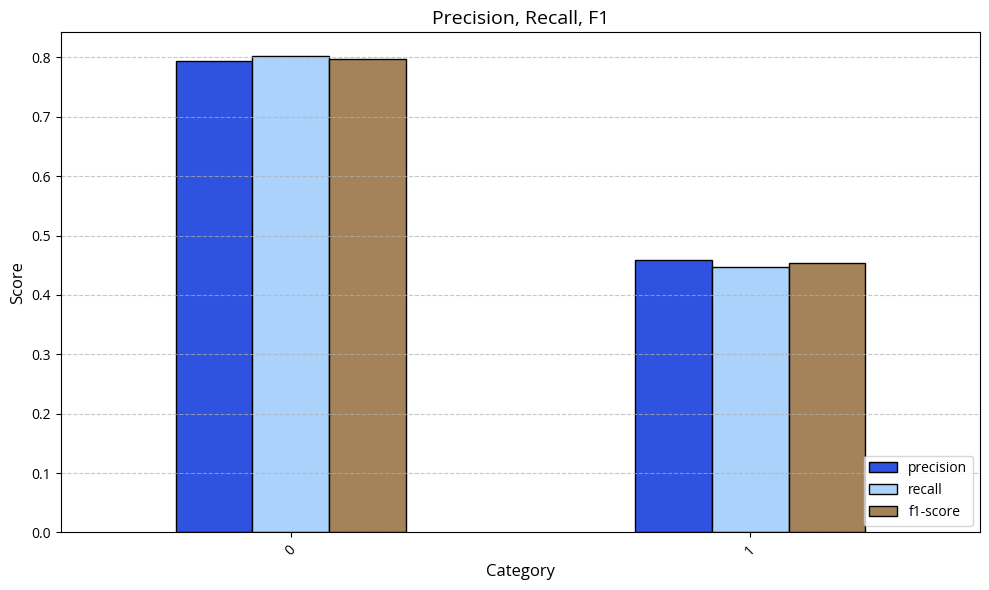

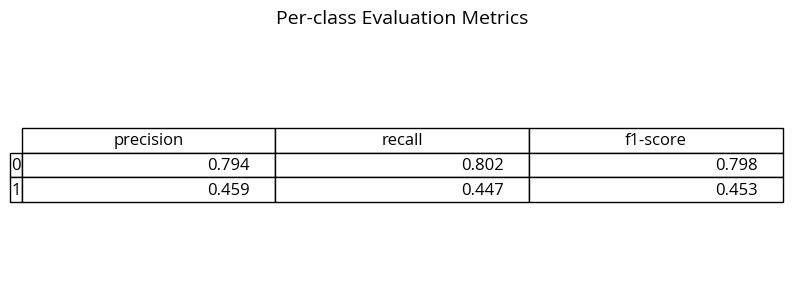

In [5]:
#Deep Feed Forward NN - MiniLM
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)


# manual booster for class 1

model, class_to_idx = train_minilm_nn(
     X_train_vec, y_train,
    X_test_vec, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64,32, 16, 8]},
    epochs=550,
    lr=0.0001
)


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.

Classification Report:
              precision    recall  f1-score   support

           0     0.8659    0.7030    0.7760       101
           1     0.4737    0.7105    0.5684        38

    accuracy                         0.7050       139
   macro avg     0.6698    0.7067    0.6722       139
weighted avg     0.7586    0.7050    0.7192       139



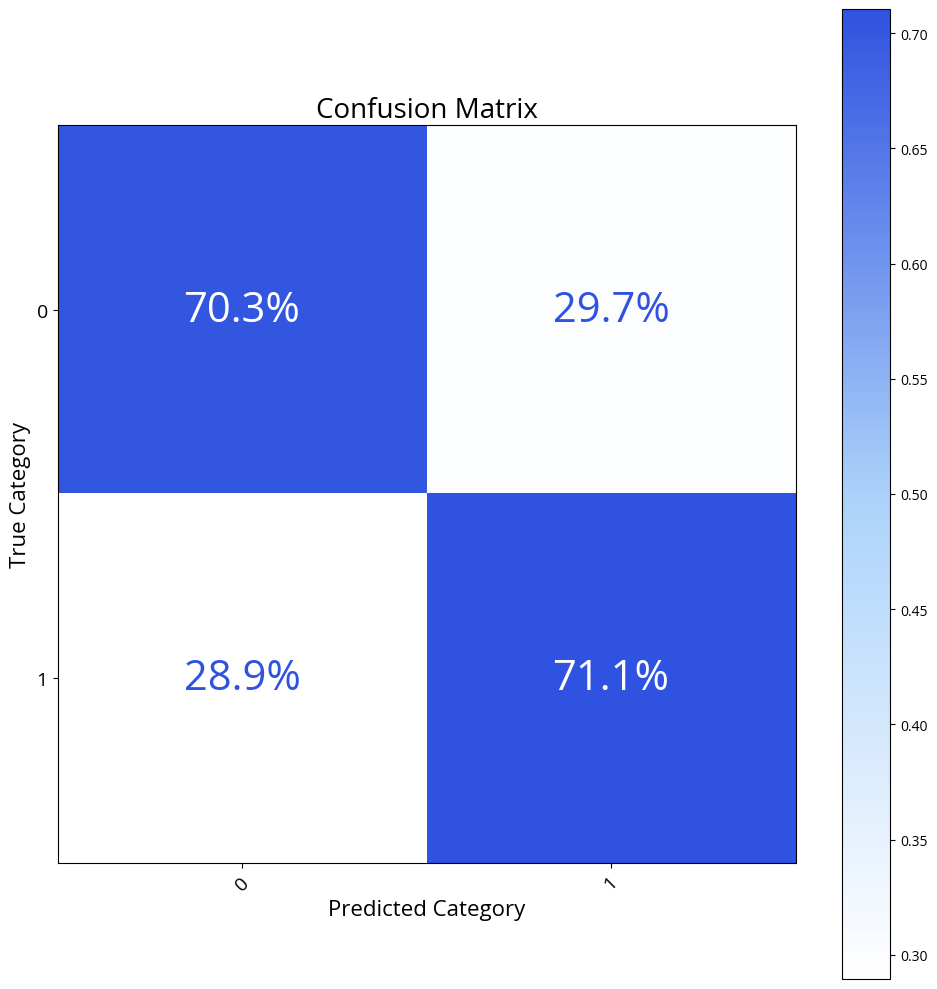

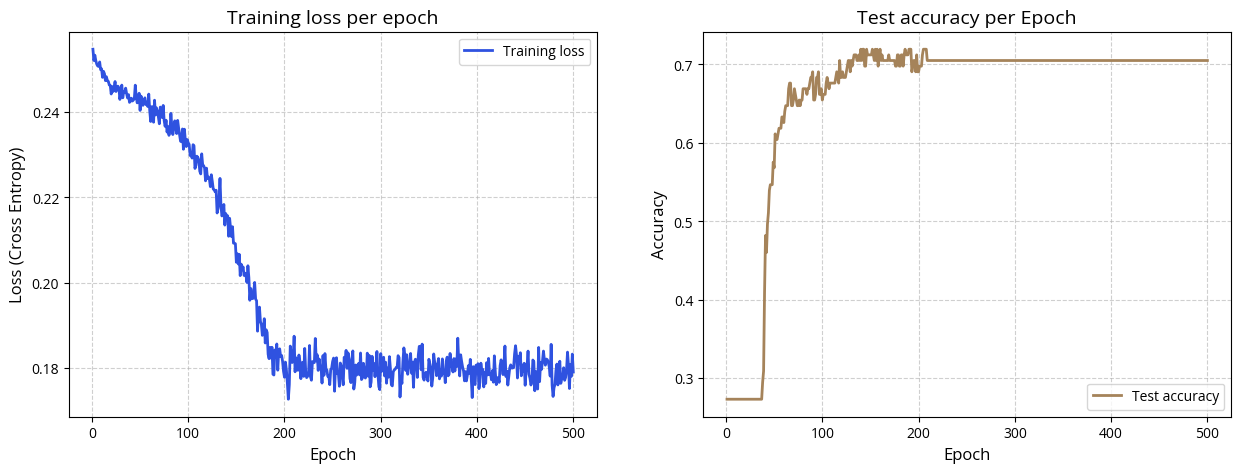

<Figure size 640x480 with 0 Axes>

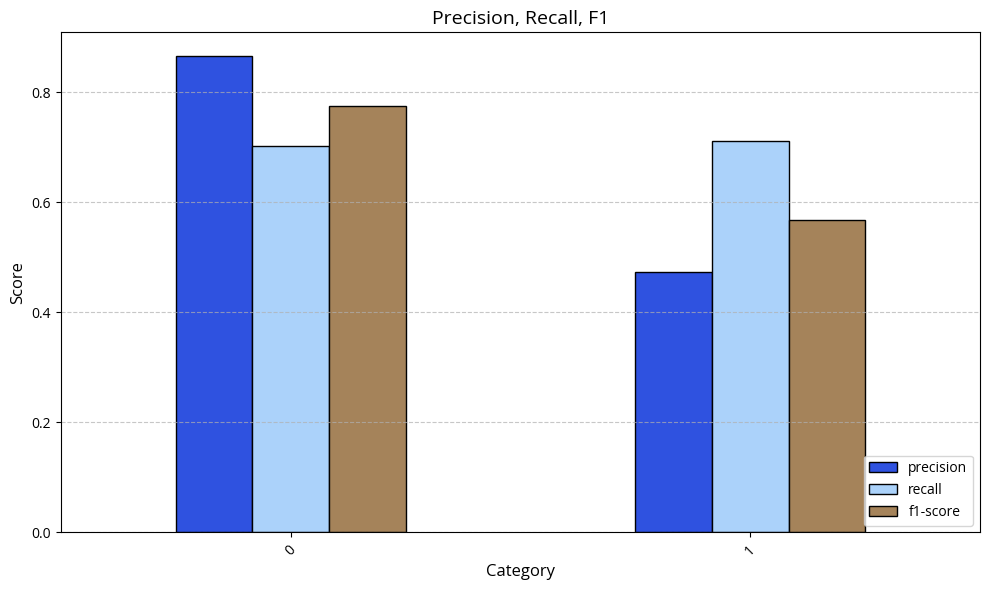

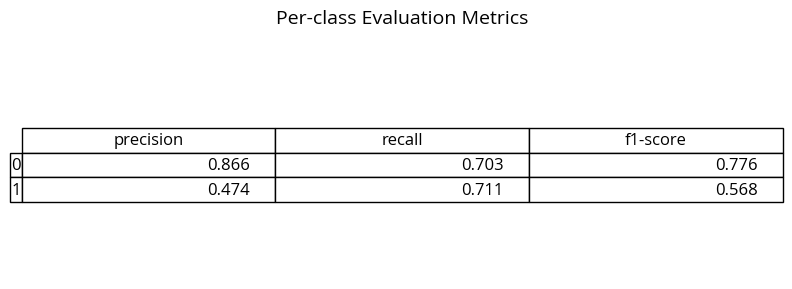

In [6]:
from src.ML.train_NN import train_nn_with_focal_loss
from torch.utils.data import TensorDataset, DataLoader
import torch 


print(df["Category"].value_counts(normalize=True))


device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.map({cls: i for i, cls in enumerate(sorted(set(y_train)))}).values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.map({cls: i for i, cls in enumerate(sorted(set(y_train)))}).values, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


#Deep Feed Forward NN - MiniLM with Focal Loss
input_dim = X_train_vec.shape[1]
output_dim = len(set(y_train))
model = DeepTextClassifier(input_dim=input_dim, output_dim=output_dim, hidden_dims=[256, 128, 64])

# FOCAL LOSS

trained_model = train_nn_with_focal_loss(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=500,
    lr=1e-5,
    alpha=torch.tensor([1.0, 2.5], device=device),  
    gamma=2.0,
    use_scheduler=True,
    device=device
)
